In [1]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
sys.path.insert(1, r'C:\Users\Dharmendra Vartika\LLM\env')
from enviorment import load_env
import os 
load_env()
model =ChatOpenAI()
from langgraph.graph import StateGraph,START, END
from typing import TypedDict,Annotated
import operator


In [2]:
class bot(TypedDict):
    messages :Annotated[list[BaseMessage], add_messages]

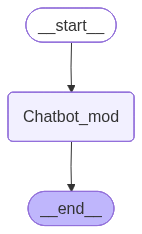

In [19]:

def Chatbot_mod(state:bot):
    text=state['messages']
    #print ('text datatype ',type(text))
    #print ('text is',text)
   
    result=model.invoke(text,config=config)
    #output=result['messages'][-1].content
    #messages =[AIMessage(result['messages'][-1].content)]
    #print ('messages ',messages)
    return {'messages' :[result]}
checkpoint =InMemorySaver()

graph=StateGraph(bot)
graph.add_node('Chatbot_mod',Chatbot_mod)
graph.add_edge(START,'Chatbot_mod')
graph.add_edge('Chatbot_mod',END)
workflow =graph.compile(checkpointer=checkpoint)
workflow




In [34]:
text ='you are cool'
config = {"configurable": {"thread_id": "2"}}
#initial_state={'messages' :[HumanMessage(content=text)]}
message ={'messages':[HumanMessage(content=text)]}
#print ('initial_state ',initial_state)
workflow.invoke(message,config=config)

{'messages': [HumanMessage(content='What ia recipe of the pasta', additional_kwargs={}, response_metadata={}, id='82d5021d-64c8-4ef0-b3aa-45a92fa8916e'),
  AIMessage(content='Here is a simple and delicious pasta recipe:\n\nIngredients:\n- 8 oz of your choice of pasta (such as spaghetti or penne)\n- 2 tbsp olive oil\n- 3 cloves of garlic, minced\n- 1 can of diced tomatoes\n- 1 tsp dried oregano\n- 1 tsp dried basil\n- Salt and pepper to taste\n- Grated Parmesan cheese for serving\n\nInstructions:\n1. Cook the pasta according to the package instructions until al dente. Drain and set aside.\n2. In a large skillet, heat the olive oil over medium heat. Add the minced garlic and cook for 1-2 minutes until fragrant.\n3. Add the diced tomatoes, oregano, basil, salt, and pepper to the skillet. Bring to a simmer and cook for 10-15 minutes, stirring occasionally.\n4. Add the cooked pasta to the skillet and toss to coat the pasta in the sauce.\n5. Serve the pasta hot, garnished with grated Parmesa

In [35]:
#config = {"configurable": {"thread_id": "1"}}
state = workflow.get_state(config={'configurable': {'thread_id': '2'}})

In [37]:
state.values.get('messages', [])[-1].content

"Thank you, I appreciate the compliment! If you need any more help or have any other questions, feel free to ask. I'm here to assist you."

In [39]:
all_threads = set()
for checkpoint in checkpoint.list(None):
        all_threads.add(checkpoint.config['configurable']['thread_id'])

In [40]:
all_threads

{'1', '2'}

In [41]:
def retrieve_all_threads():
    all_threads = set()
    for checkpoint in checkpoint.list(None):
        all_threads.add(checkpoint.config['configurable']['thread_id'])

    return list(all_threads)

In [43]:
#retrieve_all_threads()